# Cell 1 — Clone repo

In [3]:
%cd /kaggle/working
!rm -rf /kaggle/working/ddpm-from-scratch
!git clone https://github.com/Zanteni/ddpm-from-scratch.git /kaggle/working/ddpm-from-scratch

/kaggle/working
Cloning into '/kaggle/working/ddpm-from-scratch'...
remote: Enumerating objects: 373, done.
remote: Counting objects: 100% (373/373), done.
remote: Compressing objects: 100% (208/208), done.
remote: Total 373 (delta 178), reused 316 (delta 121), pack-reused 0 (from 0)
Receiving objects: 100% (373/373), 1.38 MiB | 10.07 MiB/s, done.
Resolving deltas: 100% (178/178), done.


# Cell 2 — Install package

In [4]:
%cd /kaggle/working/ddpm-from-scratch
!pip install -e . -q

/kaggle/working/ddpm-from-scratch
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ddpm (pyproject.toml) ... done


# Cell 3 — Imports

In [5]:
import sys
sys.path.insert(0, "/kaggle/working/ddpm-from-scratch/src")
import torch
from ddpm.models.unet import UNet
from ddpm.diffusion.schedules import get_beta_schedule, get_diffusion_constants
from ddpm.datasets.cifar10 import get_cifar10_dataloader, get_cifar10_dataloader_from_folder
from ddpm.trainers.trainer import train
from ddpm.utils.checkpoint import save_checkpoint
from ddpm.utils.seed import set_seed


# Cell 4 — Setup (seed, device, schedule, model, data, optimizer)

In [7]:
set_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- Diffusion schedule ---
timesteps = 1000
betas = get_beta_schedule("linear", timesteps)
consts = get_diffusion_constants(betas)
sqrt_alphas_cumprod = consts["sqrt_alphas_cumprod"].to(device)
sqrt_one_minus_alphas_cumprod = consts["sqrt_one_minus_alphas_cumprod"].to(device)

# --- Model ---
model = UNet(
    in_channels=3, base_channels=128, channel_mults=(1, 2, 4),
    time_emb_dim=512, num_layers=2, num_groups=32,
    image_size=32, attn_resolution=16,
)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = torch.nn.DataParallel(model)

model = model.to(device)
# --- Data ---
dataloader = get_cifar10_dataloader_from_folder(
    root="/kaggle/input/datasets/ayush1220/cifar10/cifar10/train",
    batch_size=64,
    shuffle=True,
)
# --- Optimizer ---
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50) # T_max = num_epochs
print(type(model))
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Number of batches per epoch: {len(dataloader)}")

Using device: cuda
Using 2 GPUs!
<class 'torch.nn.parallel.data_parallel.DataParallel'>
Model parameters: 37,205,891
Number of batches per epoch: 782


# Cell 5 — Run training

In [18]:
import os

os.makedirs("checkpoints", exist_ok=True)

checkpoint_path = "checkpoints/latest.pt"
start_epoch = 0

if os.path.exists(checkpoint_path):
    start_epoch = load_checkpoint(
        model,
        optimizer,
        scheduler,
        path=checkpoint_path,
        device=device,
    )
    start_epoch += 1
    print(f"Resuming training from epoch {start_epoch}")
else:
    print("No checkpoint found, starting fresh")

epochs_per_chunk = 5
total_epochs = 20
epochs_done = start_epoch

while epochs_done < total_epochs:
    remaining = min(epochs_per_chunk, total_epochs - epochs_done)

    print(f"\nTraining epochs {epochs_done + 1} to {epochs_done + remaining}")

    trained_model = train(
        model,
        dataloader,
        optimizer,
        timesteps,
        sqrt_alphas_cumprod,
        sqrt_one_minus_alphas_cumprod,
        num_epochs=remaining,
        device=device,
        log_every=100,
        checkpoint_path=checkpoint_path,
        scheduler=scheduler,
    )

    epochs_done += remaining
    print(f"Completed {epochs_done}/{total_epochs} epochs")

print("Training complete.")

No checkpoint found, starting fresh

Training epochs 1 to 5
Epoch 0 | Batch 0 | Loss: 0.2039 | Time: 15:38:43
Epoch 0 | Batch 100 | Loss: 0.0923 | Time: 15:41:41
Epoch 0 | Batch 200 | Loss: 0.0787 | Time: 15:44:40
Epoch 0 | Batch 300 | Loss: 0.0432 | Time: 15:47:40
Epoch 0 | Batch 400 | Loss: 0.0687 | Time: 15:50:39
Epoch 0 | Batch 500 | Loss: 0.0402 | Time: 15:53:36
Epoch 0 | Batch 600 | Loss: 0.0405 | Time: 15:56:37
Epoch 0 | Batch 700 | Loss: 0.0251 | Time: 15:59:39
Epoch 0/5 | avg loss 0.0610 | lr 2.00e-04 | Time: 16:02:08
Saved checkpoint after epoch 0
Epoch 1 | Batch 0 | Loss: 0.0551 | Time: 16:02:10
Epoch 1 | Batch 100 | Loss: 0.0532 | Time: 16:04:32
Epoch 1 | Batch 200 | Loss: 0.0594 | Time: 16:06:57
Epoch 1 | Batch 300 | Loss: 0.0515 | Time: 16:09:21
Epoch 1 | Batch 400 | Loss: 0.0514 | Time: 16:11:41
Epoch 1 | Batch 500 | Loss: 0.0228 | Time: 16:14:01
Epoch 1 | Batch 600 | Loss: 0.0414 | Time: 16:16:22
Epoch 1 | Batch 700 | Loss: 0.0336 | Time: 16:18:45
Epoch 1/5 | avg loss 0

# Cell 6 — Save checkpoint

In [21]:
import os
os.makedirs("checkpoints", exist_ok=True)
save_checkpoint(trained_model, optimizer,scheduler, epoch=20, path="checkpoints/final.pt")

# Cell 7 — Sample + view results

Saved generated_samples.png


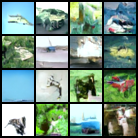

In [29]:
from ddpm.datasets.transforms import unnormalize_to_zero_to_one
from IPython.display import Image
import torchvision
from ddpm.diffusion.sampler import sample 

num_samples = 16
generated = sample(
    model,
    shape=(num_samples, 3, 32, 32),
    timesteps=timesteps,
    betas=consts["betas"].to(device),
    alphas=consts["alphas"].to(device),
    alphas_cumprod=consts["alphas_cumprod"].to(device),
    posterior_variance=consts["posterior_variance"].to(device),
    device=device,
)

generated = unnormalize_to_zero_to_one(generated)
generated = generated.clamp(0, 1)

torchvision.utils.save_image(generated, "generated_samples.png", nrow=4)
print("Saved generated_samples.png")

Image("generated_samples.png")

In [43]:
from IPython.display import FileLink
import os

print(os.getcwd())
print(os.path.exists("generated_samples.png"))
FileLink("generated_samples.png")

/kaggle/working/ddpm-from-scratch
True


/kaggle/working/ddpm-from-scratch/generated_samples.png